##### Titanic Dataset Analysis  Chapter 5: Data Visualization & Storytelling — End-to-End Case Study

**Student Name:** Kusum Pokhrel  
**Course:** Advance python programming for Data Science
**Date:** 08 March 2026  
**Dataset:** Titanic Passenger Dataset (source: Kaggle / Seaborn built-in)

##### 1. Introduction & Dataset Overview

This project analyzes the Titanic passenger dataset to understand factors that influenced survival.  
The dataset contains passenger information such as age, gender, ticket class, fare paid, and survival status.

Source:
https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv

Research Questions:
- Did gender affect survival?
- Did passenger class affect survival?
- Is there a relationship between fare and age?

In [6]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
#load datasets
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#inspect dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [ ]:
#summary statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# check missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
#handle missing value
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [8]:
#verify missing value
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

##### Dataset Description

The Titanic dataset contains passenger information from the Titanic ship disaster.  
Important columns include:

- Survived: Whether the passenger survived (1 = Yes, 0 = No)
- Pclass: Passenger class (1 = First, 2 = Second, 3 = Third)
- Sex: Gender of the passenger
- Age: Passenger age
- Fare: Ticket price paid
- Embarked: Port where the passenger boarded

The dataset will be used to explore how factors such as gender, age, ticket class, and fare relate to survival.

##### 3. Matplotlib Visualizations
In this section we use Matplotlib to create different chart types to explore the Titanic dataset.

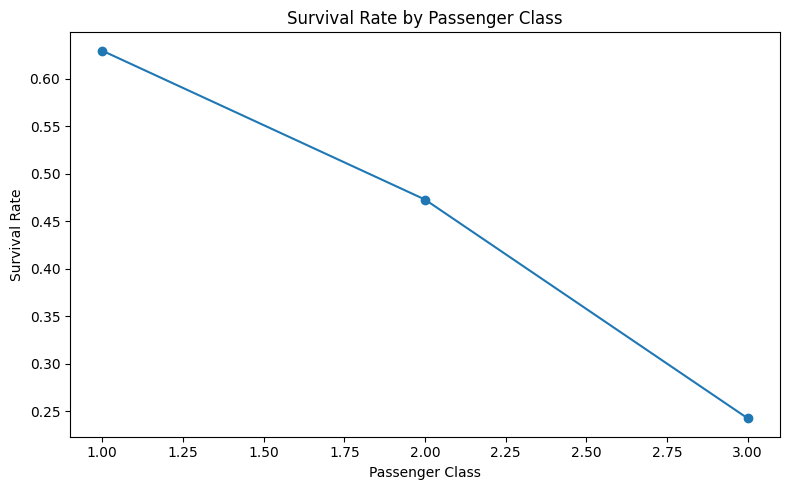

In [9]:
#line chart
plt.figure(figsize=(8,5))

survival_by_class = df.groupby("Pclass")["Survived"].mean()

plt.plot(survival_by_class.index, survival_by_class.values, marker='o')

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("line_chart.png", dpi=150)

plt.show()

Insight:

Passengers in higher classes had better survival rates. 
First-class passengers show the highest survival rate, while third-class passengers had the lowest. 
This suggests that wealth and access to resources may have influenced survival chances.

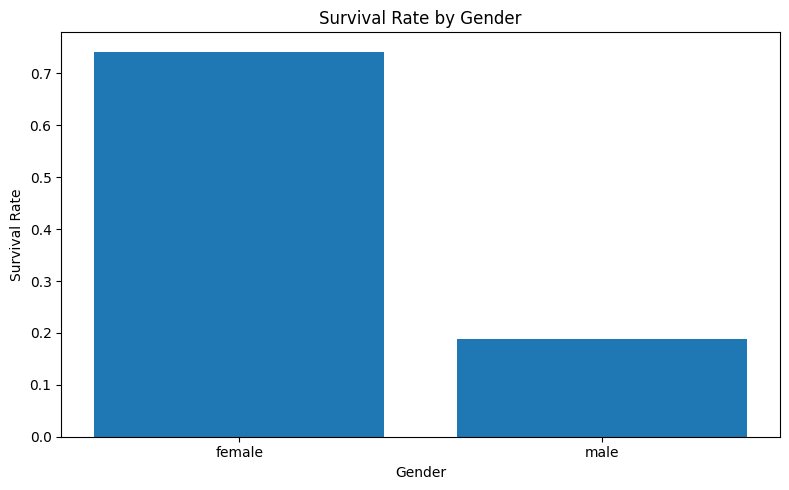

In [10]:
# Bar chart
plt.figure(figsize=(8,5))

gender_survival = df.groupby("Sex")["Survived"].mean()

plt.bar(gender_survival.index, gender_survival.values)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("bar_chart.png", dpi=150)

plt.show()

Insight:

Female passengers had a much higher survival rate compared to males. 
This reflects the historical “women and children first” evacuation policy followed during the Titanic disaster.

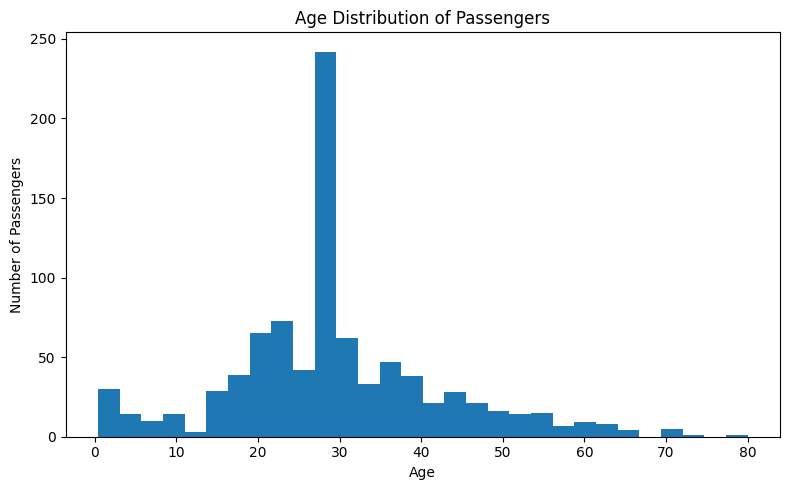

In [11]:
# histogram
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=30)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.savefig("histogram.png", dpi=150)

plt.show()

Insight:

Most passengers were young adults between ages 20 and 40. 
There are fewer elderly passengers, indicating the passenger population was mostly younger travelers.

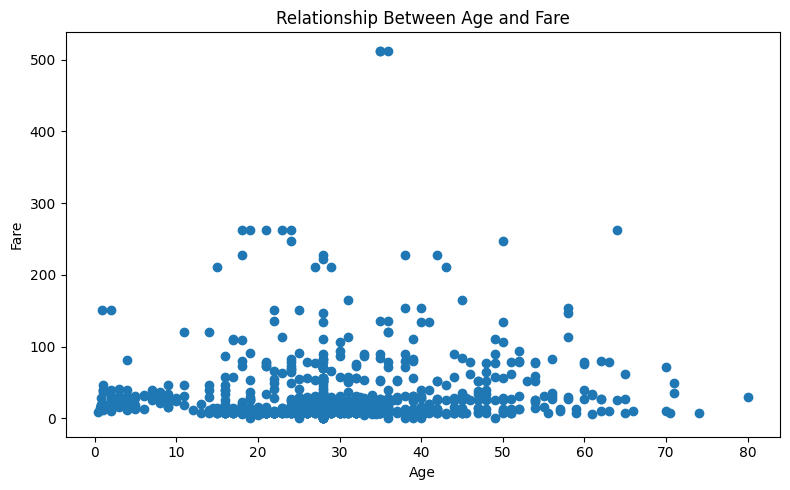

In [12]:
# Scatter plot
plt.figure(figsize=(8,5))

plt.scatter(df["Age"], df["Fare"])

plt.title("Relationship Between Age and Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.tight_layout()
plt.savefig("scatter_plot.png", dpi=150)

plt.show()

Insight:

There is no strong relationship between age and fare. 
Passengers of all ages paid a wide range of fares, suggesting ticket price depended more on class rather than age.

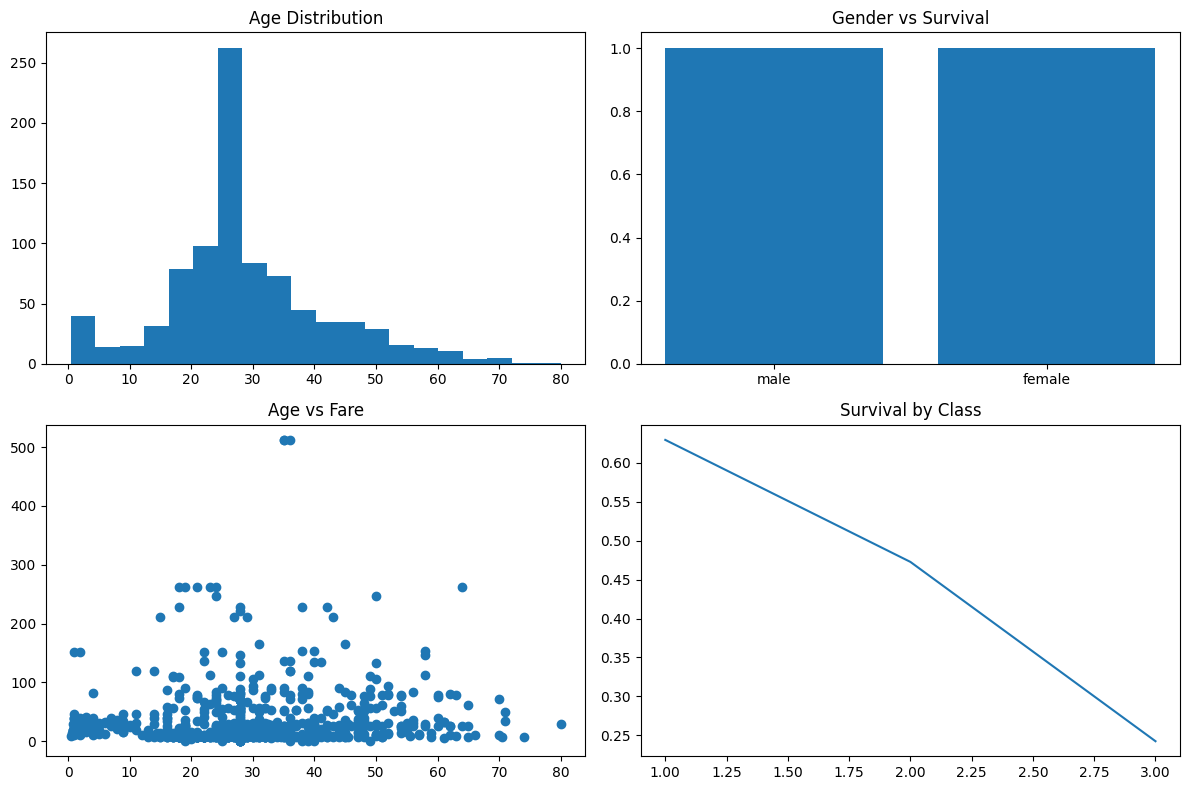

In [13]:
#Subplot Grid
fig, axes = plt.subplots(2,2, figsize=(12,8))

axes[0,0].hist(df["Age"], bins=20)
axes[0,0].set_title("Age Distribution")

axes[0,1].bar(df["Sex"], df["Survived"])
axes[0,1].set_title("Gender vs Survival")

axes[1,0].scatter(df["Age"], df["Fare"])
axes[1,0].set_title("Age vs Fare")

survival_by_class = df.groupby("Pclass")["Survived"].mean()
axes[1,1].plot(survival_by_class.index, survival_by_class.values)
axes[1,1].set_title("Survival by Class")

plt.tight_layout()
plt.savefig("subplots.png", dpi=150)

plt.show()


Insight:

The subplot grid provides a quick overview of multiple patterns in the dataset. 
It highlights how survival differs by class and gender while also showing the distribution of passenger ages and the relationship between age and fare.

##### 4. Seaborn Statistical Plots

Seaborn provides advanced statistical visualizations that help identify distributions, correlations, and relationships between variables in the dataset.

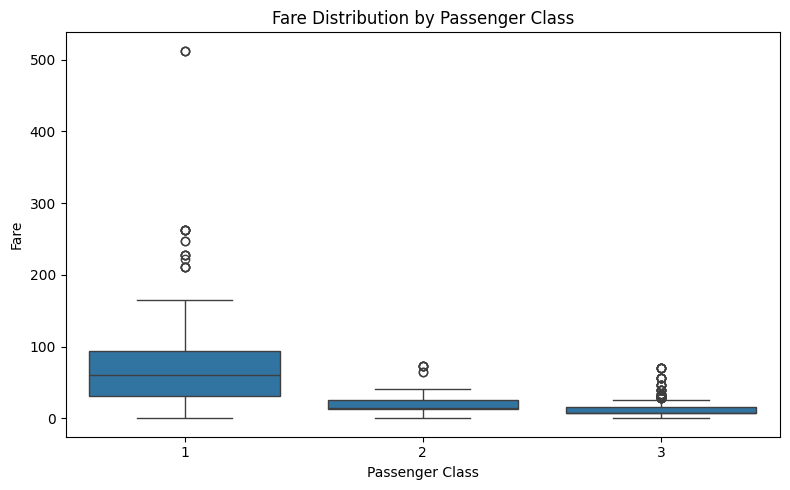

In [27]:
# Box plot
plt.figure(figsize=(8,5))

sns.boxplot(x="Pclass", y="Fare", data=df)

plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.tight_layout()
plt.savefig("boxplot.png", dpi=150)

plt.show()

Insight:

The box plot shows that first-class passengers paid significantly higher fares compared to second and third class passengers. 
There are also several outliers, indicating that some passengers paid extremely high ticket prices.

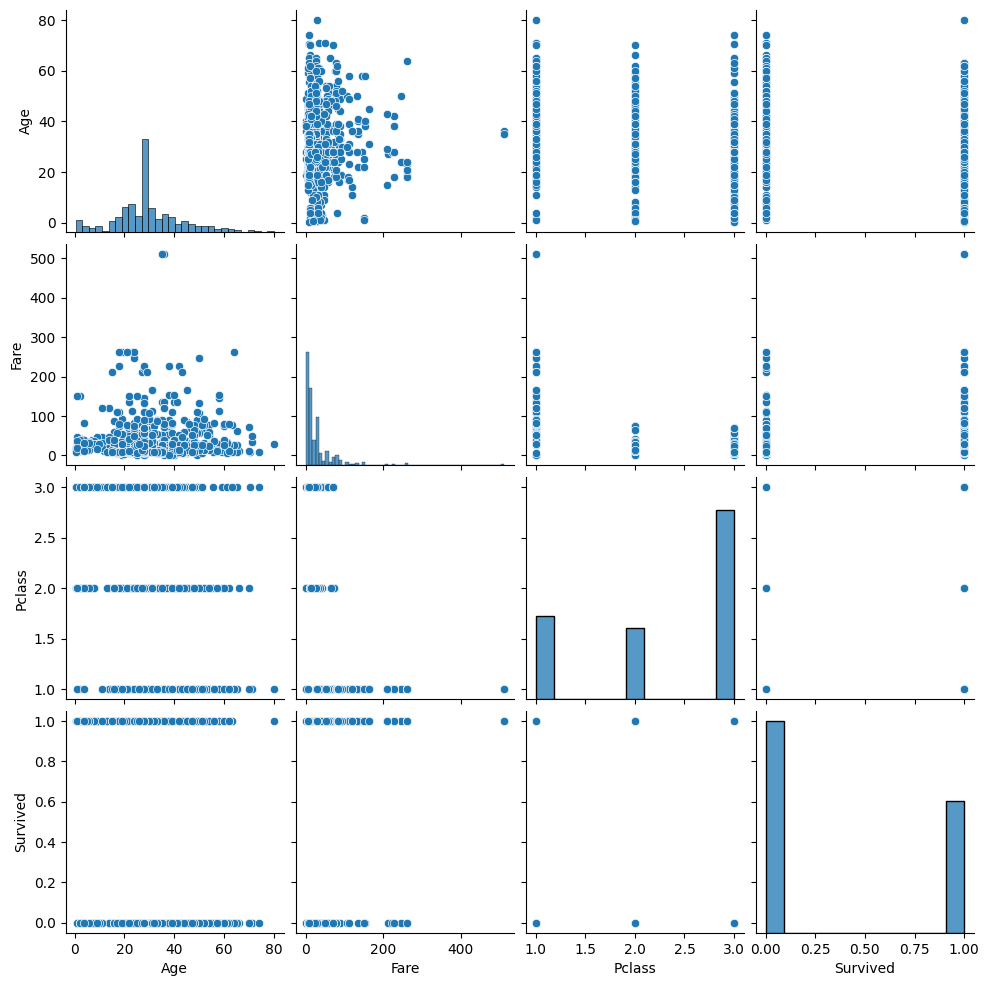

In [15]:
# Pair plot
cols = ["Age", "Fare", "Pclass", "Survived"]

sns.pairplot(df[cols])

plt.savefig("pairplot.png", dpi=150)
plt.show()

Insight:

The pair plot displays relationships between multiple numerical variables. 
It helps identify patterns such as how passenger class relates to survival and how fare varies with passenger class.

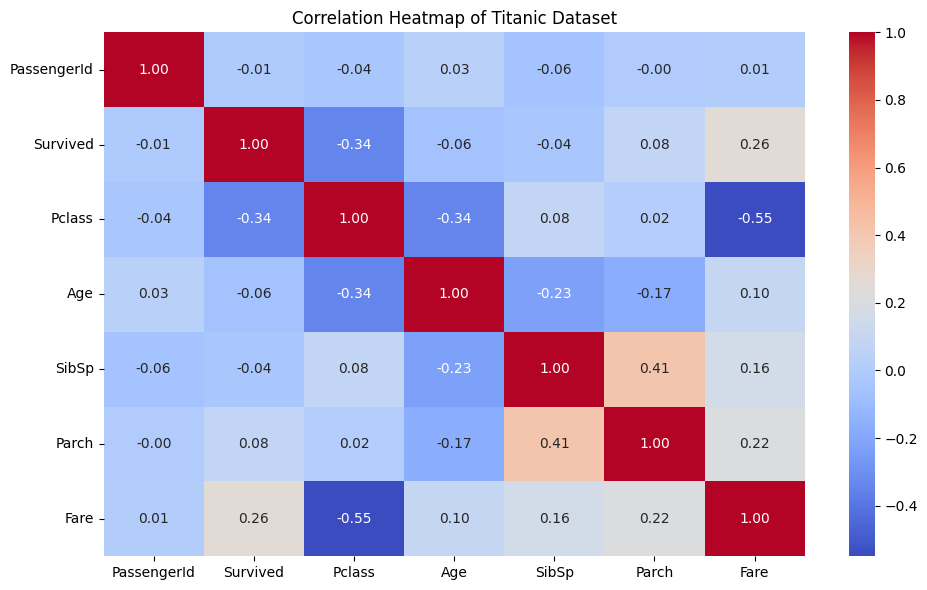

In [16]:
# Correlation Heatmap
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Titanic Dataset")

plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)

plt.show()

Insight:

The heatmap shows the strength of relationships between numerical variables. 
Passenger class has a noticeable negative correlation with survival, meaning passengers in higher classes were more likely to survive.

##### 5. Plotly Interactive Chart

We create an interactive chart to explore survival based on age, fare, and gender.

In [26]:
# Interactive Scatter Plot
fig = px.scatter(
    df, 
    x="Age", 
    y="Fare", 
    color="Sex",        # color by gender
    hover_data=["Pclass", "Survived", "Embarked"],  # extra info on hover
    title="Interactive Scatter: Age vs Fare by Gender"
)

fig.show()

In [23]:
# Export Interactive Chart as PNG
fig.write_image("plotly_scatter.png")

Insight:

The interactive scatter plot allows exploration of age and fare by gender. 
Hovering shows passenger class, survival, and embarkation port. 
We can see that female passengers cluster at higher survival rates across all ages, while fare varies widely across classes.

In [28]:
# ![Plotly Scatter](plotly_scatter.png)
fig.write_image("plotly_scatter.png")

##### 6. Insight Summary

Here we summarize the 3–5 strongest insights from the Titanic dataset based on the charts we created.


**Insight 1 — Survival by Class (Line Chart)**     
**Observation:** First-class passengers had the highest survival rate, while third-class passengers had the lowest.  
**Explanation:** Higher-class passengers had better access to lifeboats and priority during evacuation.  
**Implication:** Passenger class strongly influenced survival chances during the Titanic disaster.

**Insight 2 — Survival by Gender (Bar Chart)**   
**Observation:** Female passengers had much higher survival rates than male passengers.  
**Explanation:** The “women and children first” policy was applied during the evacuation.  
**Implication:** Gender played a critical role in survival, highlighting historical social norms in emergencies.


**Insight 3 — Age Distribution (Histogram)**   
**Observation:** Most passengers were between 20–40 years old.  
**Explanation:** The passenger population consisted mainly of younger adults, with fewer children and elderly.  
**Implication:** Age distribution may have influenced survival patterns, but younger adults were the majority group onboard.

**Insight 4 — Fare & Class Relationship (Box Plot)**  
**Observation:** First-class passengers paid significantly higher fares, with some extreme outliers.  
**Explanation:** Higher fares correspond to luxury cabins; outliers may be wealthy passengers paying extra.  
**Implication:** Fare is a strong indicator of class, which in turn affects survival.

**Insight 5 — Correlation (Heatmap)**    
**Observation:** Passenger class has a negative correlation with survival, and fare has a positive correlation.  
**Explanation:** Higher class (lower numerical value) corresponds to higher survival, and higher fare passengers are more likely to be in better class cabins.  
**Implication:** Class and fare together can be used to predict survival probabilities.

#####  7. Conclusion
**Key Finding:** Passenger class and gender were the most important factors influencing survival.  
First-class passengers and females had the highest survival rates, while third-class passengers and males had lower survival.

**Limitations:**  
- Some age and cabin data were missing and had to be imputed.  
- The dataset does not include detailed behavioral or location information during evacuation.  
- Sample size is limited to passengers onboard the Titanic only.

**Further Investigation:**  
- Analyze survival patterns for families traveling together.  
- Explore the effect of embarkation port on survival rates.  
- Use machine learning models to predict survival using multiple features.